In [1]:
from statsmodels.stats.proportion import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import yfinance as yf

In [6]:
# Define el rango de fechas
start_date = '2020-01-01'
end_date = '2024-09-30'

# Especifica el ticker de la acción que deseas obtener"
ticker = '^GSPC'

# Descarga los datos históricos
datos_historicos = yf.download(ticker, start=start_date, end=end_date)
datos_historicos

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000
...,...,...,...,...,...,...
2024-09-23,5711.899902,5725.359863,5704.220215,5718.569824,5718.569824,3529550000
2024-09-24,5727.660156,5735.319824,5698.990234,5732.930176,5732.930176,3872710000
2024-09-25,5733.649902,5741.029785,5712.060059,5722.259766,5722.259766,3624910000


In [7]:
datos_historicos["Return"] = (datos_historicos["Close"] - datos_historicos["Open"]) / datos_historicos["Open"]
datos_historicos

,Open,High,Low,Close,Adj Close,Volume,Return
Date,,,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000,0.004062
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000,0.002631
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000,0.008929
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000,-0.001444
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000,0.004465
...,...,...,...,...,...,...,...
2024-09-23,5711.899902,5725.359863,5704.220215,5718.569824,5718.569824,3529550000,0.001168
2024-09-24,5727.660156,5735.319824,5698.990234,5732.930176,5732.930176,3872710000,0.000920
2024-09-25,5733.649902,5741.029785,5712.060059,5722.259766,5722.259766,3624910000,-0.001987


In [8]:
datos_historicos['Sign'] = np.where(datos_historicos['Return'] > 0, 1, -1)
datos_historicos

,Open,High,Low,Close,Adj Close,Volume,Return,Sign
Date,,,,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000,0.004062,1
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000,0.002631,1
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000,0.008929,1
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000,-0.001444,-1
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000,0.004465,1
...,...,...,...,...,...,...,...,...
2024-09-23,5711.899902,5725.359863,5704.220215,5718.569824,5718.569824,3529550000,0.001168,1
2024-09-24,5727.660156,5735.319824,5698.990234,5732.930176,5732.930176,3872710000,0.000920,1
2024-09-25,5733.649902,5741.029785,5712.060059,5722.259766,5722.259766,3624910000,-0.001987,-1


In [9]:
# Crear grupos donde el signo cambia
grupo = (datos_historicos['Sign'] != datos_historicos['Sign'].shift()).cumsum()

# Contar días consecutivos dentro de cada grupo
datos_historicos['ConsecCount'] = datos_historicos.groupby(grupo).cumcount() + 1

# Asignar signos positivos o negativos a la cuenta
datos_historicos['Consec'] = datos_historicos['ConsecCount'] * datos_historicos['Sign']
datos_historicos

,Open,High,Low,Close,Adj Close,Volume,Return,Sign,ConsecCount,Consec
Date,,,,,,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000,0.004062,1,1,1
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000,0.002631,1,2,2
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000,0.008929,1,3,3
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000,-0.001444,-1,1,-1
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000,0.004465,1,1,1
...,...,...,...,...,...,...,...,...,...,...
2024-09-23,5711.899902,5725.359863,5704.220215,5718.569824,5718.569824,3529550000,0.001168,1,1,1
2024-09-24,5727.660156,5735.319824,5698.990234,5732.930176,5732.930176,3872710000,0.000920,1,2,2
2024-09-25,5733.649902,5741.029785,5712.060059,5722.259766,5722.259766,3624910000,-0.001987,-1,1,-1


Cosas a tener en cuenta, puede ser cuando sea 5 dias consecutivos, pero tambien podemos tener en cuenta cuando sean 5 o más.

In [20]:
# Inicializar la columna de señales
datos_historicos['Signal'] = 0

# Señal de compra después de 5 días negativos consecutivos
neg_condition = (datos_historicos['Consec'] <= -5)
datos_historicos.loc[neg_condition.shift(1).fillna(False), 'Signal'] = 1

# # Señal de compra después de 2 días positivos consecutivos
# pos_condition = (datos_historicos['Consec'] == 2)
# datos_historicos.loc[pos_condition.shift(1).fillna(False), 'Signal'] = 1
# datos_historicos
datos_historicos

,Open,High,Low,Close,Adj Close,Volume,Return,Sign,ConsecCount,Consec,Signal,Intraday_Return,Strategy_Return,Cumulative_Strategy_Return,Cumulative_Asset_Return
Date,,,,,,,,,,,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000,0.004062,1,1,1,0,0.004062,0.0,0.000000,0.004062
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000,0.002631,1,2,2,0,0.002631,0.0,0.000000,0.006704
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000,0.008929,1,3,3,0,0.008929,0.0,0.000000,0.015693
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000,-0.001444,-1,1,-1,0,-0.001444,-0.0,0.000000,0.014227
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000,0.004465,1,1,1,0,0.004465,0.0,0.000000,0.018755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-23,5711.899902,5725.359863,5704.220215,5718.569824,5718.569824,3529550000,0.001168,1,1,1,0,0.001168,0.0,0.017142,0.239305
2024-09-24,5727.660156,5735.319824,5698.990234,5732.930176,5732.930176,3872710000,0.000920,1,2,2,0,0.000920,0.0,0.017142,0.240445
2024-09-25,5733.649902,5741.029785,5712.060059,5722.259766,5722.259766,3624910000,-0.001987,-1,1,-1,0,-0.001987,-0.0,0.017142,0.237981


In [21]:
# Calcular el retorno intradiario (de apertura a cierre)
datos_historicos['Intraday_Return'] = (datos_historicos['Close'] - datos_historicos['Open']) / datos_historicos['Open']

# Inicializar columna para el retorno de la estrategia
datos_historicos['Strategy_Return'] = 0

# Aplicar el retorno de la estrategia cuando hay una señal
datos_historicos['Strategy_Return'] = datos_historicos['Signal'] * datos_historicos['Intraday_Return']

# Calcular el rendimiento acumulado de la estrategia
datos_historicos['Cumulative_Strategy_Return'] = (1 + datos_historicos['Strategy_Return']).cumprod() - 1

# Calcular el rendimiento acumulado del activo (buy and hold)
datos_historicos['Cumulative_Asset_Return'] = (1 + datos_historicos['Return']).cumprod() - 1
datos_historicos

,Open,High,Low,Close,Adj Close,Volume,Return,Sign,ConsecCount,Consec,Signal,Intraday_Return,Strategy_Return,Cumulative_Strategy_Return,Cumulative_Asset_Return
Date,,,,,,,,,,,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000,0.004062,1,1,1,0,0.004062,0.0,0.000000,0.004062
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000,0.002631,1,2,2,0,0.002631,0.0,0.000000,0.006704
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000,0.008929,1,3,3,0,0.008929,0.0,0.000000,0.015693
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000,-0.001444,-1,1,-1,0,-0.001444,-0.0,0.000000,0.014227
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000,0.004465,1,1,1,0,0.004465,0.0,0.000000,0.018755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-23,5711.899902,5725.359863,5704.220215,5718.569824,5718.569824,3529550000,0.001168,1,1,1,0,0.001168,0.0,0.070116,0.239305
2024-09-24,5727.660156,5735.319824,5698.990234,5732.930176,5732.930176,3872710000,0.000920,1,2,2,0,0.000920,0.0,0.070116,0.240445
2024-09-25,5733.649902,5741.029785,5712.060059,5722.259766,5722.259766,3624910000,-0.001987,-1,1,-1,0,-0.001987,-0.0,0.070116,0.237981


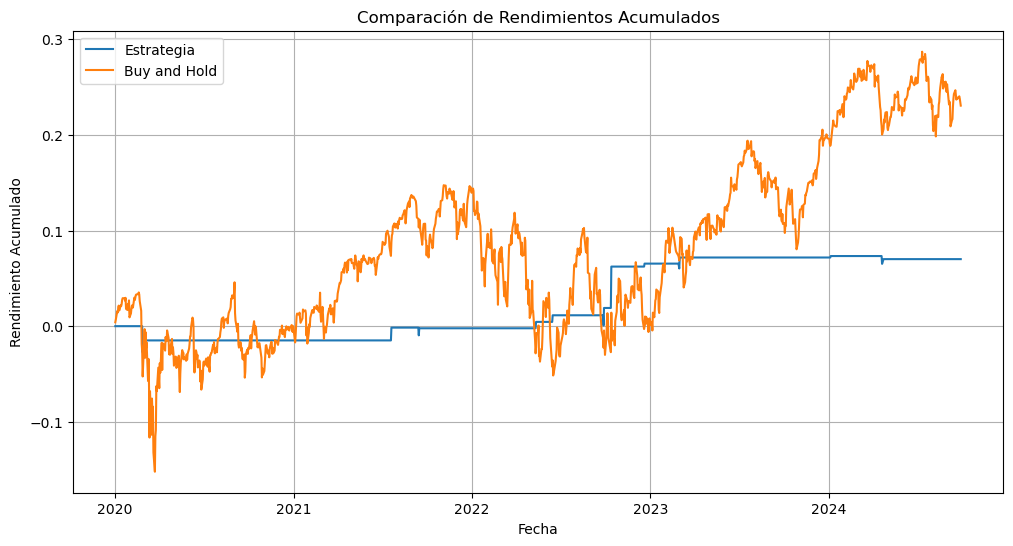

In [22]:
plt.figure(figsize=(12,6))
plt.plot(datos_historicos.index, datos_historicos['Cumulative_Strategy_Return'], label='Estrategia')
plt.plot(datos_historicos.index, datos_historicos['Cumulative_Asset_Return'], label='Buy and Hold')
plt.legend()
plt.title('Comparación de Rendimientos Acumulados')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado')
plt.grid(True)
plt.show()

In [23]:
# Retorno total de la estrategia
total_return_strategy = datos_historicos['Cumulative_Strategy_Return'].iloc[-1]
print(f"Retorno total de la estrategia: {total_return_strategy*100:.2f}%")

# Retorno total del activo (Buy and Hold)
total_return_asset = datos_historicos['Cumulative_Asset_Return'].iloc[-1]
print(f"Retorno total del activo (Buy and Hold): {total_return_asset*100:.2f}%")

# Volatilidad anualizada de la estrategia
volatility_strategy = datos_historicos['Strategy_Return'].std() * np.sqrt(252)
print(f"Volatilidad anualizada de la estrategia: {volatility_strategy*100:.2f}%")

# Retorno anualizado de la estrategia
annual_return_strategy = (1 + total_return_strategy) ** (252 / len(datos_historicos)) - 1
print(f"Retorno anualizado de la estrategia: {annual_return_strategy*100:.2f}%")

# Ratio de Sharpe (asumiendo tasa libre de riesgo de 0%)
risk_free_rate = 0.01  # Puedes ajustar la tasa libre de riesgo aquí
excess_return_strategy = annual_return_strategy - risk_free_rate
sharpe_ratio_strategy = excess_return_strategy / volatility_strategy
print(f"Ratio de Sharpe de la estrategia: {sharpe_ratio_strategy:.2f}")

# Número total de operaciones (contando señales de compra)
num_trades = datos_historicos['Signal'].sum()
print(f"Número total de operaciones: {int(num_trades)}")


Retorno total de la estrategia: 7.01%
Retorno total del activo (Buy and Hold): 23.07%
Volatilidad anualizada de la estrategia: 2.83%
Retorno anualizado de la estrategia: 1.44%
Ratio de Sharpe de la estrategia: 0.51
Número total de operaciones: 17
